# Visualize specific patches for figure

## Pretraining images

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/aj12-lg1e-j_a_p04_26005_29513_3407__orig.png


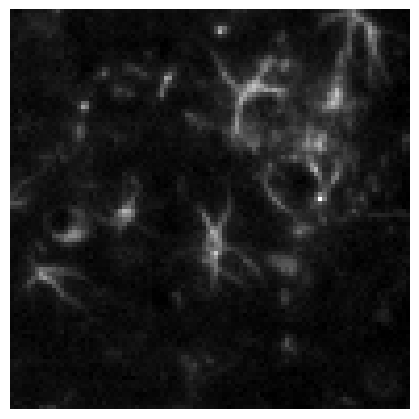

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/aj12-lg1e-j_a_p04_26005_29513_3407__aug_p075.png


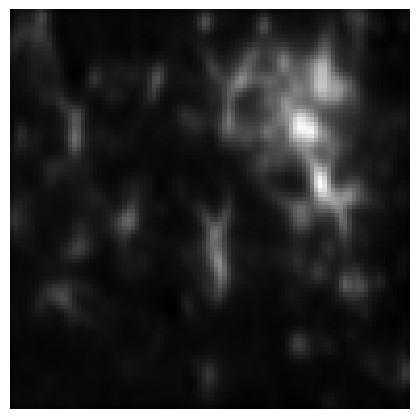

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/sma_artery_sample2_C01_ps96_p1_cand1865_z576_y672_x1536__orig.png


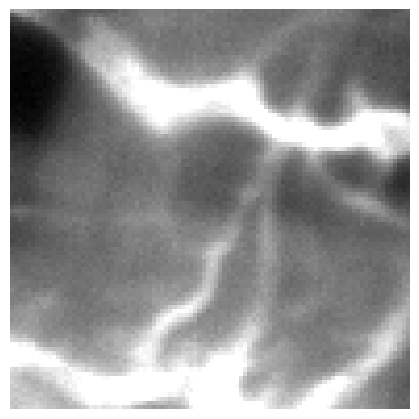

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/sma_artery_sample2_C01_ps96_p1_cand1865_z576_y672_x1536__aug_p075.png


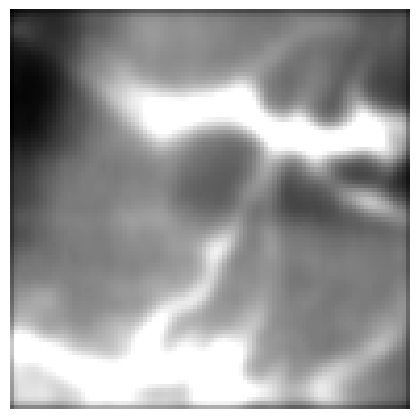

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/sub-I46_ses-SPIM_sample-BrocaAreaS14_stain-Calretinin_chunk-06_SPIM_ps96_p0_z96_y192_x3168__orig.png


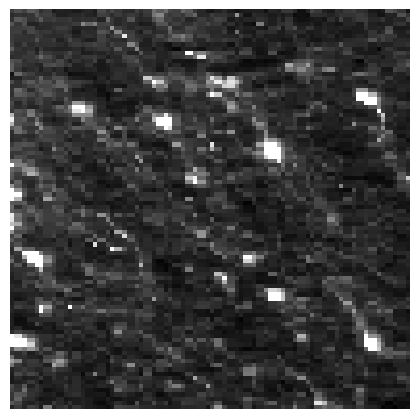

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/sub-I46_ses-SPIM_sample-BrocaAreaS14_stain-Calretinin_chunk-06_SPIM_ps96_p0_z96_y192_x3168__aug_p075.png


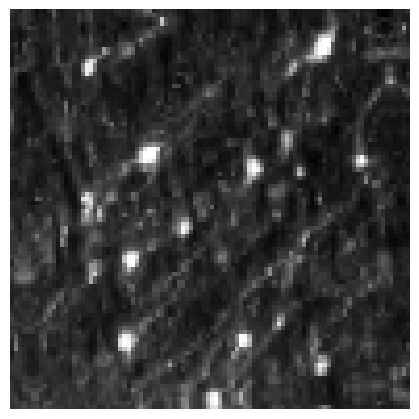

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/Neurofilament_ps96_p4_z672_y1824_x576__orig.png


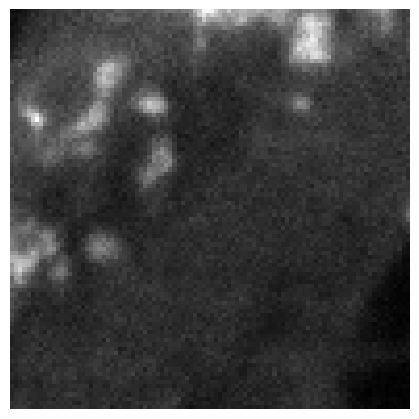

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/Neurofilament_ps96_p4_z672_y1824_x576__aug_p075.png


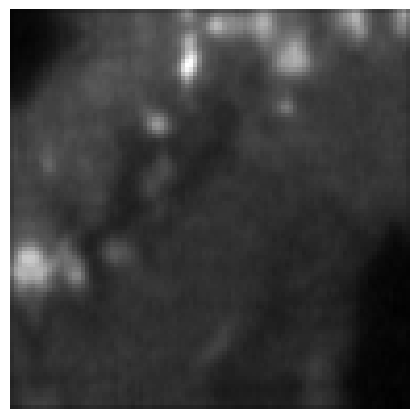

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/20211001_09_50_54_SW210318_07_LS_4X_2000z_ps96_p7_z2955_y3181_x3027_c0__orig.png


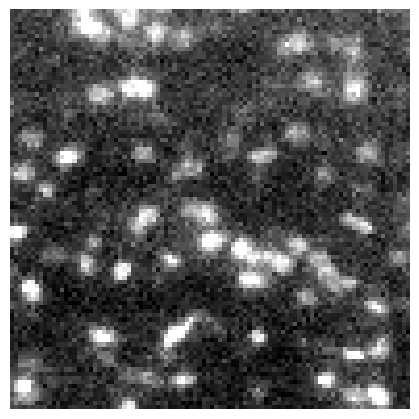

Saving: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/20211001_09_50_54_SW210318_07_LS_4X_2000z_ps96_p7_z2955_y3181_x3027_c0__aug_p075.png


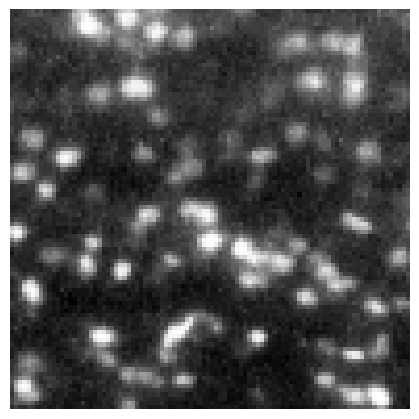


Done. PNGs saved to: /midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches


In [ ]:
# imports
import sys
from pathlib import Path
import re

import numpy as np
import torch
import matplotlib.pyplot as plt

# config
OUTDIR = Path("/midtier/paetzollab/scratch/ads4015/lsm_fm_paper/figs/image_patches/pretraining")
OUTDIR.mkdir(parents=True, exist_ok=True)

IMAGE_PATHS = [
    "/midtier/paetzollab/scratch/ads4015/all_wu_brain_patches/22_AJ12-LG1E-j_A/input/aj12-lg1e-j_a_p04_26005_29513_3407.nii.gz",
    "/midtier/paetzollab/scratch/ads4015/all_selma_patches_96/sma_artery/sma_artery_sample2_C01_ps96_p1_cand1865_z576_y672_x1536.nii.gz",
    "/midtier/paetzollab/scratch/ads4015/all_allen_human2_patches/sub-146/sub-I46_ses-SPIM_sample-BrocaAreaS14_stain-Calretinin_chunk-06_SPIM_ps96_p0_z96_y192_x3168.nii.gz",
    "/midtier/paetzollab/scratch/ads4015/all_allen_developing_mouse_patches/Neurofilament_ps96_p4_z672_y1824_x576.nii.gz",
    "/midtier/paetzollab/scratch/ads4015/all_allen_connection_projection_patches/20211001_09_50_54_SW210318_07_LS_4X_2000z/c0/20211001_09_50_54_SW210318_07_LS_4X_2000z_ps96_p7_z2955_y3181_x3027_c0.nii.gz",
]

# transforms from file
tf_path = "/home/ads4015/ssl_project/src"
if tf_path not in sys.path:
    sys.path.append(tf_path)

from all_datasets_transforms import get_load_transforms, ClampIntensityd

from monai.transforms import (
    Compose,
    RandAffined,
    RandFlipd,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    ToTensord,
)

# helpers
def safe_stem(p: str) -> str:
    """Make a filesystem-safe stem from a .nii.gz path."""
    name = Path(p).name
    name = re.sub(r"\.nii(\.gz)?$", "", name)  # strip nii/nii.gz
    name = re.sub(r"[^A-Za-z0-9._-]+", "_", name)  # sanitize
    return name

def to_3d_numpy(x) -> np.ndarray:
    """Convert MONAI output to a (H, W, D) numpy volume."""
    if torch.is_tensor(x):
        x = x.detach().cpu()
    x = x.squeeze()  # remove singleton dims

    # Common: (C,H,W,D) -> take channel 0
    if x.ndim == 4:
        x = x[0]

    if x.ndim != 3:
        raise ValueError(f"Expected 3D volume after squeeze/channel handling, got shape {tuple(x.shape)}")
    return x.numpy()

def center_slice_xy(vol_hwd: np.ndarray) -> np.ndarray:
    """Return center slice along Z as (H,W) array."""
    z = vol_hwd.shape[2] // 2
    return vol_hwd[:, :, z]

def show_and_save_slice(slc_hw: np.ndarray, out_png: Path, title: str = None, dpi: int = 300):
    """
    Display slice in notebook with no border and save PNG with no border.
    """
    # Create a figure with axes that fill the whole canvas
    fig = plt.figure(figsize=(4, 4), frameon=False)
    ax = plt.Axes(fig, [0, 0, 1, 1])
    ax.set_axis_off()
    fig.add_axes(ax)

    # .T + origin lower gives a consistent orientation (optional; remove .T if you dislike it)
    ax.imshow(slc_hw.T, cmap="gray", origin="lower")

    if title is not None:
        # Titles add margin, so skip by default; if you want titles, they will reintroduce whitespace.
        pass

    plt.show()

    # Save with no border
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

# build transforms
load_tf = get_load_transforms(target_size=None)

# train transforms with prob=0.75 each (same as in file, just higher prob so images more likely to be transformed)
train_tf_075 = Compose([
    RandFlipd(keys=["image"], spatial_axis=[0, 1, 2], prob=0.75),
    RandRotate90d(keys=["image"], prob=0.75, max_k=3),
    RandAffined(keys=["image"], rotate_range=(0.1, 0.1, 0.1), scale_range=(0.1, 0.1, 0.1), prob=0.75),

    RandGaussianNoised(keys=["image"], prob=0.75, mean=0.0, std=0.02),
    RandGaussianSmoothd(keys=["image"], prob=0.75),
    RandScaleIntensityd(keys=["image"], factors=0.2, prob=0.75),
    RandShiftIntensityd(keys=["image"], offsets=0.2, prob=0.75),
    ClampIntensityd(keys=["image"], minv=0.0, maxv=1.0),

    ToTensord(keys=["image"]),
])

# process each image
for p in IMAGE_PATHS:
    stem = safe_stem(p)

    # ----- ORIGINAL (load + center slice) -----
    loaded = load_tf({"image": p})
    vol0 = to_3d_numpy(loaded["image"])
    slc0 = center_slice_xy(vol0)

    out0 = OUTDIR / f"{stem}__orig.png"
    print(f"Saving: {out0}")
    show_and_save_slice(slc0, out0)

    # ----- AUGMENTED (load + train_075 + center slice) -----
    aug = train_tf_075(loaded)
    vol1 = to_3d_numpy(aug["image"])
    slc1 = center_slice_xy(vol1)

    out1 = OUTDIR / f"{stem}__aug_p075.png"
    print(f"Saving: {out1}")
    show_and_save_slice(slc1, out1)

print("\nDone. PNGs saved to:", OUTDIR)


## Finetuning images